In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data

df = pd.read_csv('nl_monthly.csv')

df.head()

,utc_timestamp,NL_load_actual_entsoe_transparency
0,2015-01-01 00:00:00+00:00,392469.583333
1,2015-02-01 00:00:00+00:00,336715.625000
2,2015-03-01 00:00:00+00:00,353968.541667
3,2015-04-01 00:00:00+00:00,319292.750000
4,2015-05-01 00:00:00+00:00,313571.083333


In [47]:
# Select data for training # 
fra = '2015'
til = '2020'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
df = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
df = df.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'consumption'})

df.head()

,ds,consumption
0,2015-01-01 00:00:00+00:00,392469.583333
1,2015-02-01 00:00:00+00:00,336715.625000
2,2015-03-01 00:00:00+00:00,353968.541667
3,2015-04-01 00:00:00+00:00,319292.750000
4,2015-05-01 00:00:00+00:00,313571.083333


In [48]:
print(len(df))


60


In [49]:
# Convert the time column to datetime and set as index
# Replace 'timestamp_column' with the actual name in your CSV
df['timestamp'] = pd.to_datetime(df['ds'])
df = df.set_index('timestamp').sort_index()

# Quick check for missing hours
print(f"Dataset range: {df.index.min()} to {df.index.max()}")
df.head()

Dataset range: 2015-01-01 00:00:00+00:00 to 2019-12-01 00:00:00+00:00


,ds,consumption
timestamp,,
2015-01-01 00:00:00+00:00,2015-01-01 00:00:00+00:00,392469.583333
2015-02-01 00:00:00+00:00,2015-02-01 00:00:00+00:00,336715.625000
2015-03-01 00:00:00+00:00,2015-03-01 00:00:00+00:00,353968.541667
2015-04-01 00:00:00+00:00,2015-04-01 00:00:00+00:00,319292.750000
2015-05-01 00:00:00+00:00,2015-05-01 00:00:00+00:00,313571.083333


In [50]:
print(len(df))


60



# Engineering features

In [51]:
import numpy as np

df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds')

df['month'] = df['ds'].dt.month
df['year'] = df['ds'].dt.year

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['lag1'] = df['consumption'].shift(1)
df['lag2'] = df['consumption'].shift(2)
df['lag3'] = df['consumption'].shift(3)
df['lag12'] = df['consumption'].shift(12)
df = df.dropna()

# Define features and target

#features = ['month', 'lag1', 'lag2', 'lag3', 'lag12']
features = ['month', 'month_sin', 'month_cos','year', 'lag1', 'lag2', 'lag3', 'lag12']

target = 'consumption'

# Split
train = df[df['ds'] < '2019-01-01']
valid = df[df['ds'] >= '2019-01-01']


X_train, y_train = train[features], train[target]
X_test, y_test = valid[features], valid[target]

In [52]:
print(len(df))
print(len(train))
print(len(valid))

48
36
12


In [53]:
import lightgbm as lgb
import numpy as np
import pandas as pd

def preprocess_data(X):
    # Convert to pandas DataFrame if it's not already
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    
    # Check for and remove constant features
    non_constant_cols = [col for col in X.columns if X[col].nunique() > 1]
    if len(non_constant_cols) < X.shape[1]:
        print(f"Removed {X.shape[1] - len(non_constant_cols)} constant features")
        X = X[non_constant_cols]
    
    # Check for and handle NaN values
    if X.isna().any().any():
        print("Filling NaN values with column means")
        X = X.fillna(X.mean())
    
    return X

# The function definition for preprocess_data seems to be missing from your snippet
# I'll assume it exists elsewhere in your code

# Preprocess the data
X_train = preprocess_data(X_train)
X_test = preprocess_data(X_test)

# Make sure X_test has the same columns as X_train
# This ensures feature names match between training and prediction
# First check which columns are common between the two dataframes
common_columns = [col for col in X_train.columns if col in X_test.columns]

# Use only common columns for both datasets
X_train = X_train[common_columns]
X_test = X_test[common_columns]

# Ensure y values are appropriate
y_train = np.array(y_train).ravel()
y_test = np.array(y_test).ravel()

# Check if we have enough data and features
if X_train.shape[0] < 50:
    print(f"Warning: Small dataset with only {X_train.shape[0]} samples")
if X_train.shape[1] == 0:
    raise ValueError("No features available for training after preprocessing")

# Adjust model parameters for small dataset
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,  # Slightly higher learning rate
    num_leaves=15,       # Reduced from 31 for small dataset
    min_child_samples=2, # Lower threshold for small dataset (default is 20)
    min_data_in_bin=2,   # Lower threshold (default is 3)
    importance_type='gain',
    verbose=1,
    random_state=42      # Added for reproducibility
)

# Train the model with adjusted parameters
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20)]  # Removed the verbose parameter
)

# Print feature importances to understand which features are useful
if hasattr(model, 'feature_importances_'):
    importances = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    print("\nFeature importances:")
    print(importances)

Removed 1 constant features
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 111
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 7
[LightGBM] [Info] Start training from score 396481.600694
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[55]	valid_0's l2: 6.74242e+07

Feature importances:
     feature    importance
2  m

In [54]:
y_pred= model.predict(X_test)


In [55]:
y_pred


array([438167.77720913, 393725.40191219, 405417.4906266 , 368330.1736635 ,
       377452.90462562, 377451.25930532, 386298.63502923, 380751.14222358,
       379264.13091905, 401705.12407358, 420161.55241767, 435565.72066616])

# Option 2

import lightgbm as lgb

# LightGBM Dataset parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03, # Lower learning rate for small datasets
    'num_leaves': 20,      # Keep this small to prevent overfitting 365 rows
    'feature_fraction': 0.8
}

train_data = lgb.Dataset(train_df[features], label=train_df['consumption'])
test_data = lgb.Dataset(test_df[features], label=test_df['consumption'], reference=train_data)

model = lgb.train(params, train_data, valid_sets=[test_data], num_boost_round=500)

In [56]:
import pandas as pd
import numpy as np

# Assuming y_test and y_pred are numpy arrays
# First, convert y_test to a DataFrame if it's not already one
if isinstance(y_test, np.ndarray):
    y_test_df = pd.DataFrame({'actual': y_test})
else:
    y_test_df = y_test

# Convert y_pred to DataFrame
df_pred = pd.DataFrame({'lgbm': y_pred})

# If y_test and y_pred have the same length and order, you can reset indices
# to ensure they align properly
y_test_df.reset_index(drop=True, inplace=True)
df_pred.reset_index(drop=True, inplace=True)

# Merge the DataFrames on their indices
result = pd.concat([y_test_df, df_pred], axis=1)

# Alternatively, if you know they have the same indices:
# result = pd.merge(y_test_df, df_pred, left_index=True, right_index=True)

In [57]:
print(result.columns)

Index(['actual', 'lgbm'], dtype='object')



# metrics rRMSE and rMAE

In [58]:
import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['actual'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['actual'] - result['lgbm']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['actual'] - result['lgbm'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)


rRMSE: 0.0208 rMAE: 0.0172 


In [59]:
city = 'Monthly The Netherland lgbm Sin_Cos'

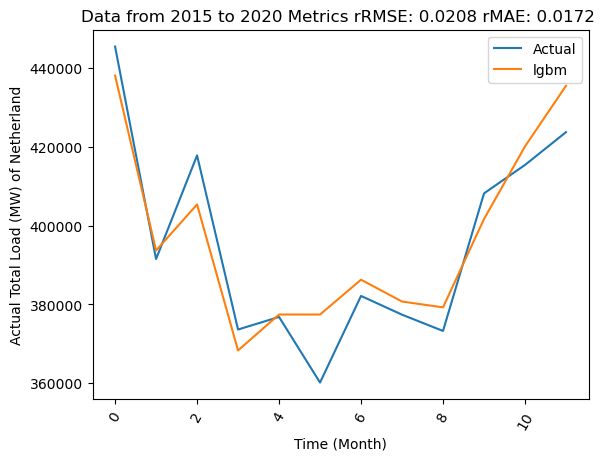

In [60]:
# plot Result dan save

plt.plot(result.index, result['actual'], label='Actual')
plt.plot(result.index, result['lgbm'],label='lgbm')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Time (Month)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of Netherland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()
